# Project — Chapter 87: Interactive Graph Explorer

> **Prerequisites:** ch056 (Visualization), ch066–070 (Transformations, Families)
>
> **Concepts:** Parameter sweeps, matplotlib widgets, function transformation, real-time update
>
> **Output:** A static parameter sweep tool with grid-based interactive panels
>
> **Difficulty:** Intermediate | ~40 minutes

---

## Stage 1 — Parameter Grid Explorer

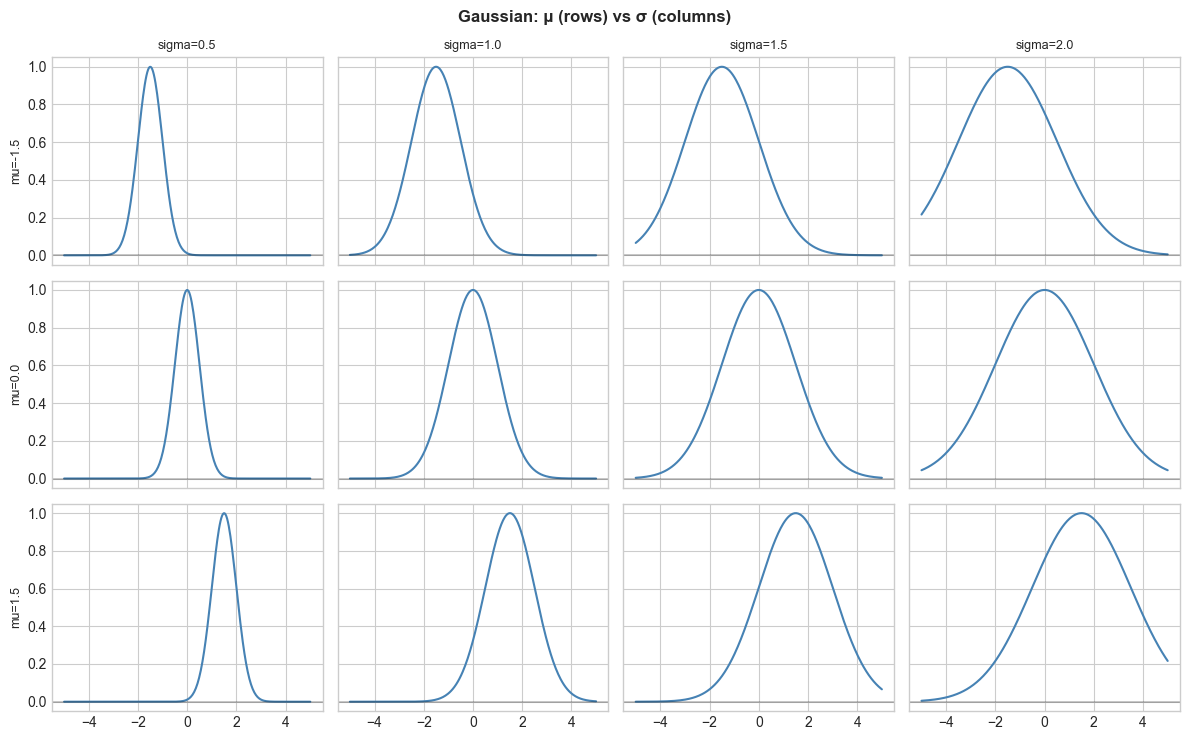

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Since ipywidgets may not be available, implement a static grid
# showing how parameters affect the function family
def explore_params(fn, param1_vals, param2_vals, p1_name, p2_name, fixed_params,
                   x=np.linspace(-3, 3, 300), title=''):
    n1, n2 = len(param1_vals), len(param2_vals)
    fig, axes = plt.subplots(n1, n2, figsize=(n2*3, n1*2.5), sharex=True, sharey=True)
    
    for i, p1 in enumerate(param1_vals):
        for j, p2 in enumerate(param2_vals):
            ax = axes[i, j] if n1 > 1 else axes[j]
            params = {**fixed_params, p1_name: p1, p2_name: p2}
            with np.errstate(invalid='ignore', over='ignore'):
                y = fn(x, **params)
            ax.plot(x, np.clip(y, -5, 5), color='steelblue', linewidth=1.5)
            ax.axhline(0, color='black', linewidth=0.3)
            if i == 0: ax.set_title(f'{p2_name}={p2:.1f}', fontsize=9)
            if j == 0: ax.set_ylabel(f'{p1_name}={p1:.1f}', fontsize=9)
    
    plt.suptitle(title or f'Function Grid: {p1_name} vs {p2_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Example: Gaussian with varying mu and sigma
explore_params(
    fn=lambda x, mu, sigma: np.exp(-(x-mu)**2 / (2*sigma**2)),
    param1_vals=[-1.5, 0, 1.5],
    param2_vals=[0.5, 1.0, 1.5, 2.0],
    p1_name='mu', p2_name='sigma',
    fixed_params={},
    x=np.linspace(-5, 5, 300),
    title='Gaussian: μ (rows) vs σ (columns)'
)

---

## Stage 2 — Transformation Chain Visualizer

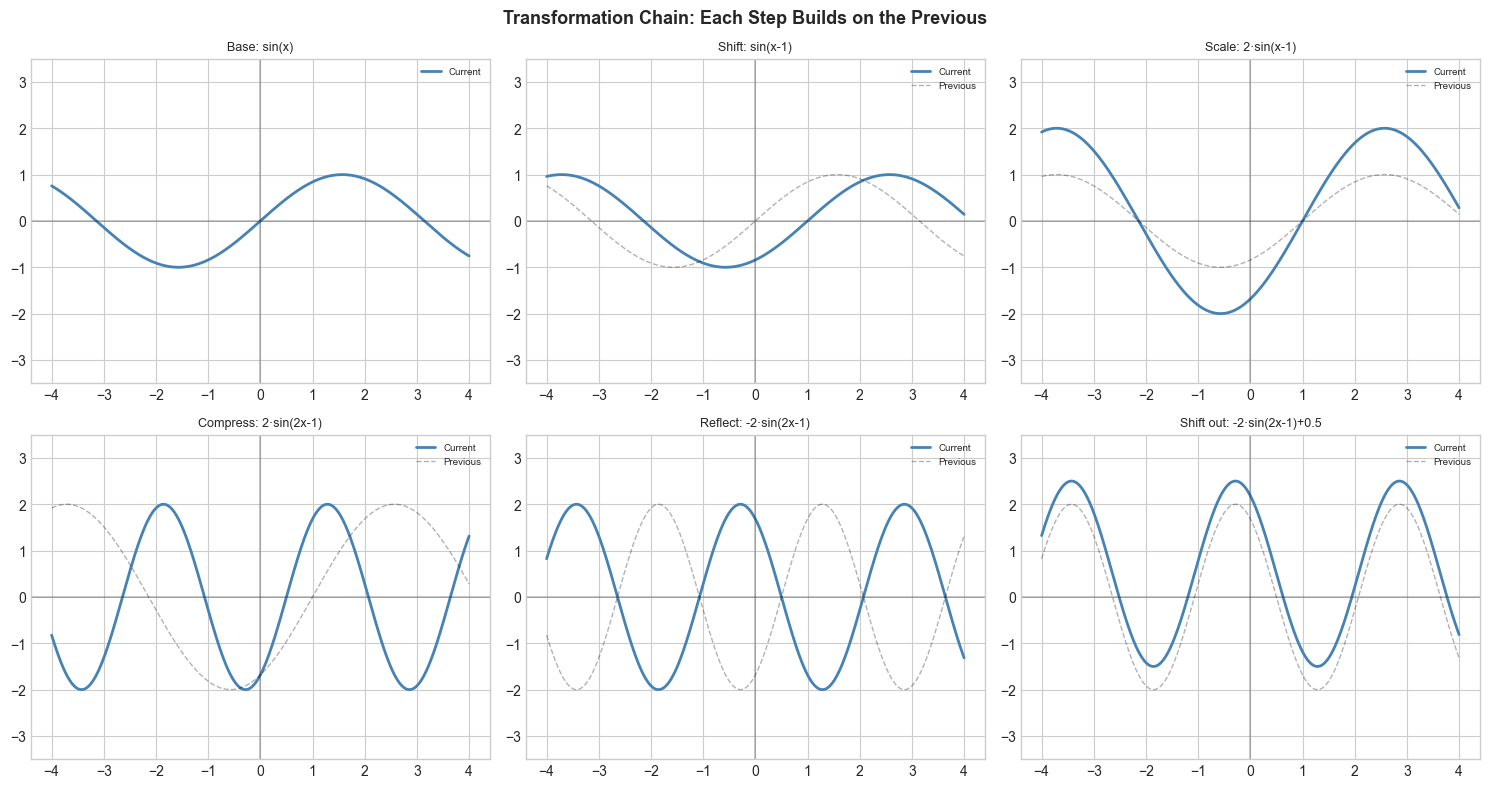

In [3]:
# Show how composing transformations changes a function
x = np.linspace(-4, 4, 400)
base = np.sin

transformations = [
    ("Base: sin(x)", lambda x: np.sin(x)),
    ("Shift: sin(x-1)", lambda x: np.sin(x - 1)),
    ("Scale: 2·sin(x-1)", lambda x: 2 * np.sin(x - 1)),
    ("Compress: 2·sin(2x-1)", lambda x: 2 * np.sin(2*x - 1)),
    ("Reflect: -2·sin(2x-1)", lambda x: -2 * np.sin(2*x - 1)),
    ("Shift out: -2·sin(2x-1)+0.5", lambda x: -2*np.sin(2*x-1) + 0.5),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
prev_f = None
for ax, (label, f) in zip(axes.flat, transformations):
    y = f(x)
    ax.plot(x, y, color='steelblue', linewidth=2, label='Current')
    if prev_f is not None:
        ax.plot(x, prev_f(x), 'k--', linewidth=1, alpha=0.3, label='Previous')
    ax.axhline(0, color='black', linewidth=0.3); ax.axvline(0, color='black', linewidth=0.3)
    ax.set_title(label, fontsize=9); ax.set_ylim(-3.5, 3.5); ax.legend(fontsize=7)
    prev_f = f
plt.suptitle('Transformation Chain: Each Step Builds on the Previous', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 3 — Sensitivity Landscape

C:\Users\user\AppData\Local\Temp\ipykernel_24584\3665530394.py:24: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


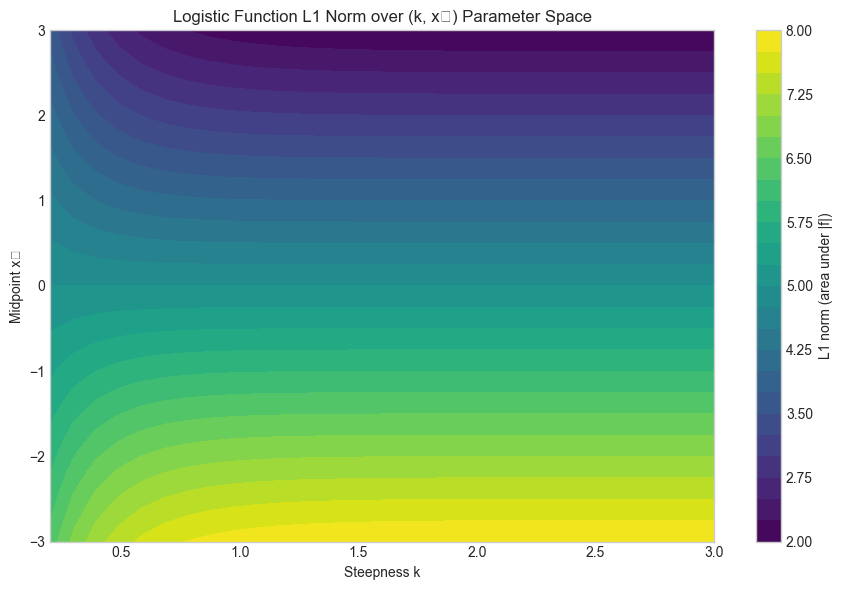

In [5]:
# Show how a metric (e.g., integral) changes over 2D parameter space
x = np.linspace(-5, 5, 300)

def functional_metric(fn, x):
    """Compute area under |f(x)| (L1 norm) as a functional metric."""
    y = np.abs(fn(x))
    return np.trapezoid(y, x)

# For logistic: metric over (k, x0) space
k_vals = np.linspace(0.2, 3.0, 30)
x0_vals = np.linspace(-3, 3, 30)
K, X0 = np.meshgrid(k_vals, x0_vals)
Z = np.zeros_like(K)
for i in range(30):
    for j in range(30):
        fn = lambda xi, k=K[i,j], x0=X0[i,j]: 1/(1+np.exp(-k*(xi-x0)))
        Z[i, j] = functional_metric(fn, x)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.contourf(K, X0, Z, levels=25, cmap='viridis')
plt.colorbar(im, ax=ax, label='L1 norm (area under |f|)')
ax.set_title('Logistic Function L1 Norm over (k, x₀) Parameter Space')
ax.set_xlabel('Steepness k'); ax.set_ylabel('Midpoint x₀')
plt.tight_layout(); plt.show()

---

## Results & Reflection

**What was built:** Parameter grid explorer, transformation chain visualizer, and sensitivity landscape map.

**Extensions:** 1) Use ipywidgets for true interactive sliders. 2) Add animation (FuncAnimation) showing parameter morphing. 3) Export selected plots to PDF.